# What factors drive bike rentals? 

### 1. Introduction: 

This project aims to analyze the key drivers of bike rental demand using both econometric and machine learning approaches. First, a hierarchical linear regression framework is employed to assess the impact of weather conditions, seasonal, temporal, and other relevant variables. This approach allows for a structured evaluation of how different groups of variables contribute to explaining demand. Second, an XGBoost model is implemented to capture potential nonlinear relationships and to assess feature importance.

The dataset used in this analysis is obtained from the OpenML platform and is based on real-world observations from a bike-sharing system. It contains detailed information on rental activity alongside weather and time-related variables.

Overall, the goal of this study is to provide a comprehensive understanding of the factors that influence bike rental demand and to compare traditional statistical methods with modern machine learning techniques in explaining and predicting usage patterns.

Bike-sharing provides a flexible, low-cost, and environmentally friendly alternative to traditional transport. As cities increasingly embrace sustainability in transport modes, understanding the factors that drive bike rental demand becomes crucial for economic policies that aim at optimal allocation of resources, pricing strategies, and service providing. The demand for bike rentals is inherently variable and susceptible to environmental conditions, temporal patterns, and user behavior.

Previous research has shown that weather conditions and temporal factors play a key role in determining bike-sharing demand. For example, Fanaee-T and Gama (2014) find that temperature and seasonal patterns drive demand. Other studies show that behavioral and temporal effects drive demand, such as convenience, financial savings, and the difference between weekend and weekday (Fishman, 2016). 

The objective of this project is to elicit the key drivers of bike rental demand using both econometric and machine learning approaches. First, a hierarchical linear regression framework is employed to assess the impact of weather conditions, seasonal effects, and temporal effects. This approach allows for a structured evaluation of how different categories of variables contribute to explaining the demand for bike rentals. Second, an XGBoost model is implemented to capture potential nonlinearities and interaction effects between variables and to rank features in terms of their contribution to explaining the demand for bike rentals.

The dataset used in this analysis is the Bike Sharing Dataset, originally introduced by Fanaee-T and Gama (2014). It is based on real-world data from the Capital Bikeshare system in Washington, D.C. The dataset is based on hourly data and covers the years 2011-2012. Weather-related factors have been obtained from several external sources and have been merged based on timestamps. The dataset is readily available on the OpenML platform. 

We will proceed with loading the dataset and creating some initial associations and visualizations, running hierarchical liniear regression model, running XGBoost model, and drawing conclusions based on our results.

### 2. Data

##### 2.1. Loading Data

We load the data and get familiar with its size and features. In addition, we employ descriptive statistics and clean the dataset if necessary. 

In [5]:
import pandas as pd
from sklearn.datasets import fetch_openml

# download dataset from OpenML
bike = fetch_openml(name="Bike_Sharing_Demand", version=2, as_frame=True)

# features
X = bike.data

# target
y = bike.target

# combine into one dataframe
df = X.copy()
df["count"] = y

df.head()

,season,year,month,hour,holiday,weekday,workingday,weather,temp,feel_temp,humidity,windspeed,count
0,spring,0,1,0,False,6,False,clear,9.84,14.395,0.81,0.0,16
1,spring,0,1,1,False,6,False,clear,9.02,13.635,0.80,0.0,40
2,spring,0,1,2,False,6,False,clear,9.02,13.635,0.80,0.0,32
3,spring,0,1,3,False,6,False,clear,9.84,14.395,0.75,0.0,13
4,spring,0,1,4,False,6,False,clear,9.84,14.395,0.75,0.0,1


In [6]:
df.shape

(17379, 13)

In [7]:
df.columns

Index(['season', 'year', 'month', 'hour', 'holiday', 'weekday', 'workingday',
       'weather', 'temp', 'feel_temp', 'humidity', 'windspeed', 'count'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   season      17379 non-null  category
 1   year        17379 non-null  int64   
 2   month       17379 non-null  int64   
 3   hour        17379 non-null  int64   
 4   holiday     17379 non-null  category
 5   weekday     17379 non-null  int64   
 6   workingday  17379 non-null  category
 7   weather     17379 non-null  category
 8   temp        17379 non-null  float64 
 9   feel_temp   17379 non-null  float64 
 10  humidity    17379 non-null  float64 
 11  windspeed   17379 non-null  float64 
 12  count       17379 non-null  int64   
dtypes: category(4), float64(4), int64(5)
memory usage: 1.3 MB


In [9]:
df.describe()

,year,month,hour,weekday,temp,feel_temp,humidity,windspeed,count
count,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,0.502561,6.537775,11.546752,3.003683,20.376474,23.788755,0.627229,12.736540,189.463088
std,0.500008,3.438776,6.914405,2.005771,7.894801,8.592511,0.192930,8.196795,181.387599
min,0.000000,1.000000,0.000000,0.000000,0.820000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,4.000000,6.000000,1.000000,13.940000,16.665000,0.480000,7.001500,40.000000
50%,1.000000,7.000000,12.000000,3.000000,20.500000,24.240000,0.630000,12.998000,142.000000
75%,1.000000,10.000000,18.000000,5.000000,27.060000,31.060000,0.780000,16.997900,281.000000
max,1.000000,12.000000,23.000000,6.000000,41.000000,50.000000,1.000000,56.996900,977.000000


In [10]:
df.isnull().sum()

season        0
year          0
month         0
hour          0
holiday       0
weekday       0
workingday    0
weather       0
temp          0
feel_temp     0
humidity      0
windspeed     0
count         0
dtype: int64

##### 2.2. Initial Visualizations

To better understand the relationship between the variables, we will generate a few scatter and box plots.

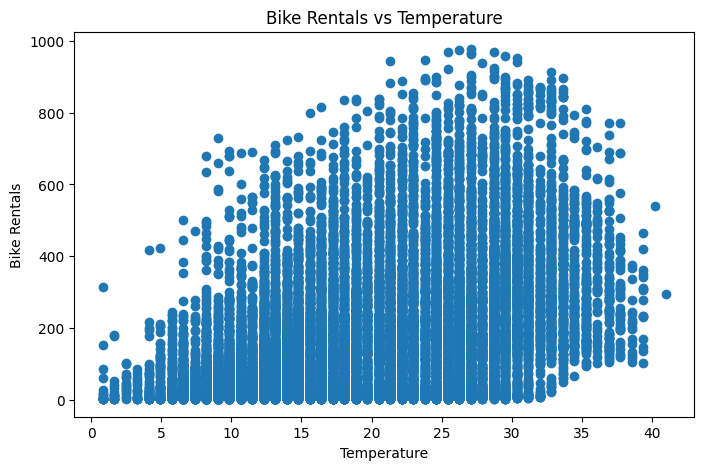

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(df["temp"], df["count"])
plt.xlabel("Temperature")
plt.ylabel("Bike Rentals")
plt.title("Bike Rentals vs Temperature")
plt.show()

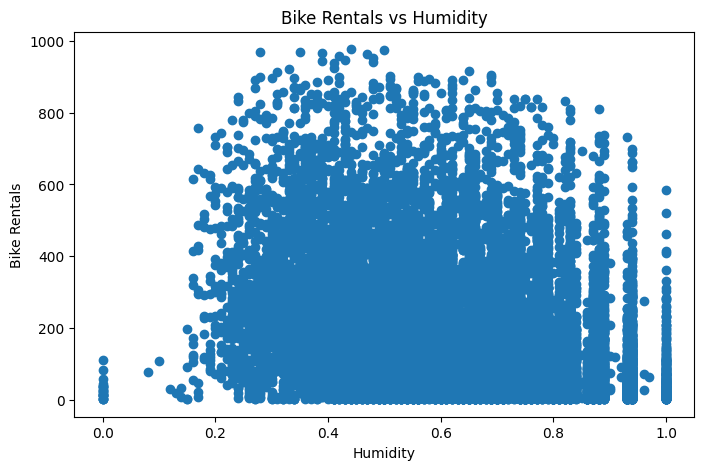

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(df["humidity"], df["count"])
plt.xlabel("Humidity")
plt.ylabel("Bike Rentals")
plt.title("Bike Rentals vs Humidity")
plt.show()

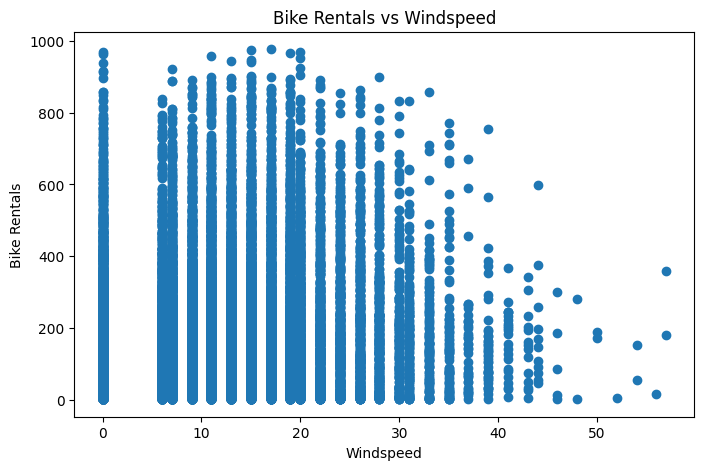

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(df["windspeed"], df["count"])
plt.xlabel("Windspeed")
plt.ylabel("Bike Rentals")
plt.title("Bike Rentals vs Windspeed")
plt.show()

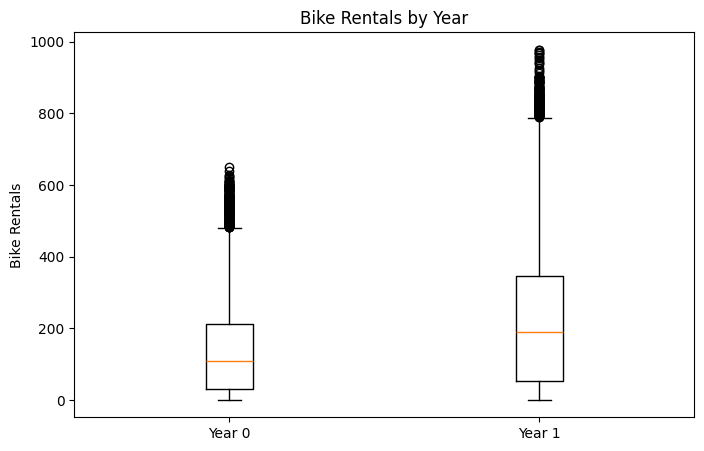

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.boxplot([
    df[df["year"] == 0]["count"],
    df[df["year"] == 1]["count"]
])

plt.xticks([1, 2], ["Year 0", "Year 1"])
plt.ylabel("Bike Rentals")
plt.title("Bike Rentals by Year")
plt.show()

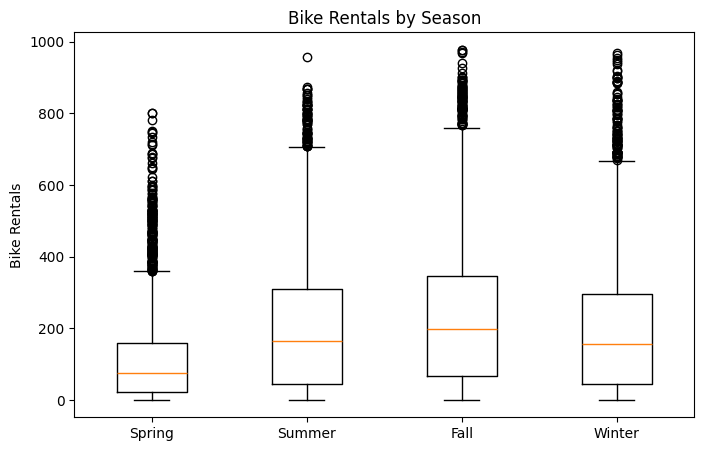

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.boxplot([
    df[df["season"] == "spring"]["count"],
    df[df["season"] == "summer"]["count"],
    df[df["season"] == "fall"]["count"],
    df[df["season"] == "winter"]["count"]
])

plt.xticks([1, 2, 3, 4], ["Spring", "Summer", "Fall", "Winter"])
plt.ylabel("Bike Rentals")
plt.title("Bike Rentals by Season")

plt.show()

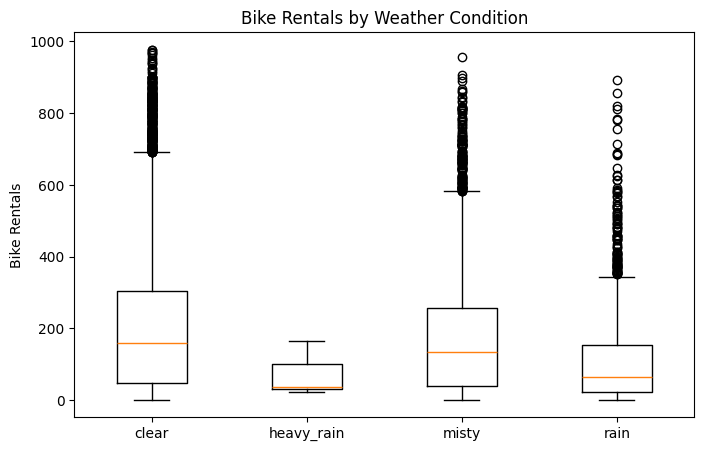

In [16]:
import matplotlib.pyplot as plt

# get unique weather values
weather_values = sorted(df["weather"].unique())

# collect data
data = [df[df["weather"] == w]["count"] for w in weather_values]

# plot
plt.figure(figsize=(8, 5))
plt.boxplot(data)

plt.xticks(range(1, len(weather_values)+1), weather_values)
plt.ylabel("Bike Rentals")
plt.title("Bike Rentals by Weather Condition")

plt.show()

##### 2.3. First Impressions

The plots reveal the following associations. There is a positive relationship between temperature and bike rentals. The relationship between humidity and bike rentals appears slightly negative, although not fully monotonic, and it is difficult to see a clear pattern. There seems to be a weak negative relationship between bike rentals, although there is a lot of noise and points are scattered. There is a higher median demand for bike rentals, more variability, and higher peak rental periods in year 1 (2012) compared to year 0 (2011). Clustering by seasons, autumn exhibits the highest bike rentals and spring the lowest bike rentals. Spring is also characterized by the lowest variability in bike rentals. Clear weather leads to the highest bike rentals with the highest variability. As weather conditions worsen, the demand for bike rentals and variability decrease. 

The initial perception from the plots is that warmer temperatures encourage people to use bicycles and increase bike rentals. Higher humidity levels decrease comfort and lead to a slight decrease in bike rentals. Very low humidity levels, however, also discourage bike rentals. Wind speed discourages bike rentals, although the data exhibits significant variability. Comparing bike rentals across years and seasons, we see that the data is right-skewed and there are many peak rental periods (and many of them fall even outside the whiskers). 

These are just some preliminary visualizations of the associations between some of the features and the variable of interest bike rentals. For simplicity, we will not show all possible relationships. The regression analysis and the XGBoost algorithm will give us a more thorough picture of what really drives the demand for bike-sharing. 

### 3. Linear Regression Model

##### 3.1. First Level (Weather-related factors):

In the beginning we use a linear regression model to quantify the relationship between the weather conditions and bike rentals. Before implementing the linear regression, we will check if there is any strong multicollinearity between the explanatory variables. The variable "weather" is categorical, so we will employ variance inflation factor analysis to test the relationship between these variables.

In [2]:
!pip install seaborn

     ------------------------------------ 294.9/294.9 kB 958.5 kB/s eta 0:00:00



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor


S = df[[
    "temp", "humidity", "windspeed",
    "weather"
]].copy()


S = pd.get_dummies(S, columns=["weather"], drop_first=True)


S = S.astype(float)


vif_data = pd.DataFrame()
vif_data["Variable"] = S.columns
vif_data["VIF"] = [
    variance_inflation_factor(S.values, i)
    for i in range(S.shape[1])
]

vif_data = vif_data.sort_values(by="VIF", ascending=False)

vif_data

,Variable,VIF
1,humidity,6.278886
0,temp,5.516194
2,windspeed,2.715199
4,weather_misty,1.539277
5,weather_rain,1.281777
3,weather_heavy_rain,1.001330


In [19]:
import statsmodels.formula.api as smf

model = smf.ols("count ~ temp + humidity + windspeed + C(weather)", data=df).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  count   R-squared:                       0.254
Model:                            OLS   Adj. R-squared:                  0.253
Method:                 Least Squares   F-statistic:                     983.4
Date:                Fri, 24 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:50:49   Log-Likelihood:            -1.1250e+05
No. Observations:               17379   AIC:                         2.250e+05
Df Residuals:                   17372   BIC:                         2.251e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

Even though the variance inflation factor analysis shows moderate coefficient values, the condition number from the regression analysis is way too high and reveals that some variables are almost linear combination of others. We see that controlling for temperature, humidity, and windspeed, only one of the categories of the variable "weather" is significant (misty compared to clear). In comparison, all the other weather-related variables (temperature, humidity, and windspeed) are highly significant even at the 1% significance level. We now test what happens when we remove the variable "weather".  

In [20]:
import statsmodels.formula.api as smf

model = smf.ols("count ~ temp + humidity + windspeed", data=df).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  count   R-squared:                       0.251
Model:                            OLS   Adj. R-squared:                  0.251
Method:                 Least Squares   F-statistic:                     1945.
Date:                Fri, 24 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:29:44   Log-Likelihood:            -1.1253e+05
No. Observations:               17379   AIC:                         2.251e+05
Df Residuals:                   17375   BIC:                         2.251e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    175.8100      6.187     28.416      0.0

R-squared decreases only slightly (from 0.254 to 0.251) and the conditional number decreases substantially (from 1930 to 180). Obviously, the variable "weather" adds very little information at the expense of multicollinearity issues. Thus, we will proceed with our analysis without considering this variable anymore. 

###### Interpretation of the linear regression results

The R-squared score of 0.251 indicates that the current model explains 25% of the variation in bike rentals. This is a moderate score (not high), indicating that there are other factors that impact bike rentals, different from weather conditions (ex. psychological factors, seasonal factors, temporal effects, etc.). 

The coefficient for temperature is 8.84 and it is significant even at the 1% significance level (p-value = 0.00). This means that a one unit increase in temperature increases bike rentals by roughly 9 units, holding other factors in the model constant. The coefficient for humidity is -273.47 and it is significant at the 1% signicicance level (p-value = 0.00). We get such a large coefficient in magnitude because humidity is measured on a scale from 0 to 1. We interpret this as a 0.1 unit increase in humidity decreases bike rentals by roughly 27 units. The coefficient for windspeed is 0.39. It is significant at the 1% signicicance level (p-value = 0.01). A unit increase in windspeed increases bike rentals by 0.4. We could alternatively say that a 10 unit increase in windspeed increases bike rentals by 4.


##### 3.2. Second-Level (Weather-related factors + Seasonal factors)

We add season, year, and month to the weather-related factors. Our first task is again to test for severe multicollinearity through the variance inflation factor analysis.  

In [21]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor


S = df[[
    "temp", "humidity", "windspeed",
    "season", "year", "month"
]].copy()


S = pd.get_dummies(S, columns=["season", "year", "month"], drop_first=True)


S = S.astype(float)


vif_data = pd.DataFrame()
vif_data["Variable"] = S.columns
vif_data["VIF"] = [
    variance_inflation_factor(S.values, i)
    for i in range(S.shape[1])
]

vif_data = vif_data.sort_values(by="VIF", ascending=False)

vif_data

,Variable,VIF
0,temp,28.751752
1,humidity,11.075359
5,season_winter,8.429215
4,season_summer,8.238191
12,month_7,6.782519
10,month_5,6.305515
13,month_8,6.295347
11,month_6,5.822615
3,season_spring,5.399537
15,month_10,5.236674


The coefficients for temperature and humidity above show a severe multicollinearity problem. We included both month and season, but these two are highly correlated. We will remove each of these separately and see what the vif coefficients reveal.  

In [22]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor


S = df[[
    "temp", "humidity", "windspeed",
    "season", "year"
]].copy()


S = pd.get_dummies(S, columns=["season", "year"], drop_first=True)


S = S.astype(float)


vif_data = pd.DataFrame()
vif_data["Variable"] = S.columns
vif_data["VIF"] = [
    variance_inflation_factor(S.values, i)
    for i in range(S.shape[1])
]

vif_data = vif_data.sort_values(by="VIF", ascending=False)

vif_data


,Variable,VIF
1,humidity,8.155761
0,temp,7.188559
2,windspeed,3.498991
3,season_spring,2.286864
5,season_winter,2.026189
6,year_1,2.004466
4,season_summer,1.892049


In [23]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor


S = df[[
    "temp", "humidity", "windspeed",
    "year", "month"
]].copy()


S = pd.get_dummies(S, columns=["year", "month"], drop_first=True)


S = S.astype(float)


vif_data = pd.DataFrame()
vif_data["Variable"] = S.columns
vif_data["VIF"] = [
    variance_inflation_factor(S.values, i)
    for i in range(S.shape[1])
]

vif_data = vif_data.sort_values(by="VIF", ascending=False)

vif_data

,Variable,VIF
0,temp,25.510672
1,humidity,7.337228
9,month_7,4.744544
10,month_8,4.296337
8,month_6,3.944664
11,month_9,3.557077
7,month_5,3.443375
2,windspeed,3.258233
12,month_10,2.720513
6,month_4,2.501930


The above results show that when we remove month, multicollinearity is much less severe than when we remove season. We will proceed with removing month from the second level regression analysis. Below is the second-level linear regression.   

In [24]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# Convert categorical variables to dummies
X = pd.get_dummies(
    df[["temp", "humidity", "windspeed", "year", "season"]],
    drop_first=True
)

y = df["count"]

# Fit model
model = LinearRegression()
model.fit(X, y)

# Coefficients
coefficients = list(zip(X.columns, model.coef_))
coefficients

import statsmodels.formula.api as smf

model = smf.ols(
    "count ~ temp + humidity + windspeed + C(season) + C(year)",
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  count   R-squared:                       0.324
Model:                            OLS   Adj. R-squared:                  0.324
Method:                 Least Squares   F-statistic:                     1191.
Date:                Fri, 24 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:36:18   Log-Likelihood:            -1.1164e+05
No. Observations:               17379   AIC:                         2.233e+05
Df Residuals:                   17371   BIC:                         2.233e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              48.5223    

###### Interpretation of the coefficients: 

The R-squared score is now 0.324. It is higher than the r-squared score of 0.251, which shows that including seasonal effects explains variation in bike rentals more than a model with weeather-related variables only. The weather-related and seasonal variables are all statistically significant even at the 1% significance level. A unit increase in temperature leads to an increase in bike rentals by close to 11, holding other factors constant. A 0.1 unit increase in humidity decreases bike rentals by about 26, holding other factors constant. A unit increase in windspeed increases bike rentals by 0.6, holding other factors constant. This is a small but statistically significant effect. Alternatively, we could stay that a 10 unit increase in windspeed increases bike rentals by about 6. 

We can clearly see strong seasonal effects in our regression results. Compared to the reference fall category, all other seasons exhibit significantly higher bike rentals on average, holding other factors constant. More specifically, compared to autumn, spring season is characterized by 37 more bike rentals on average, summer is characterized by 40 more bike rentals on average, winter is characterized by 96 more bike rentals on avarege. In addition, rentals significantly increased in the second year compared to the previous one (coefficient is 76 and it is significant). We can interpret this as a time trend that captures a variety of changes over time, but the exact nature of what these changes are is unfortunately not revealed neither in the dataset, nor in the article Fanaee-T and Gama (2014) that works with that dataset. 

###### 3.3. Third-Level (Weather-related factors + Seasonal factors + Temporal factors)

We additionally include temporal factors such as hour, weekday, and holiday. Again, first we test for multicollinerity among those variables via variance inflation factor.  

In [25]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor


S = df[[
    "temp", "humidity", "windspeed",
    "season", "year", "hour", "weekday", "holiday"
]].copy()


S = pd.get_dummies(S, columns=["season", "year", "hour", "weekday", "holiday"], drop_first=True)


S = S.astype(float)


vif_data = pd.DataFrame()
vif_data["Variable"] = S.columns
vif_data["VIF"] = [
    variance_inflation_factor(S.values, i)
    for i in range(S.shape[1])
]

vif_data = vif_data.sort_values(by="VIF", ascending=False)

vif_data


,Variable,VIF
0,temp,14.240460
1,humidity,12.268379
2,windspeed,3.685919
3,season_spring,3.434843
5,season_winter,2.658169
4,season_summer,2.126644
30,weekday_1,2.045976
6,year_1,2.022651
32,weekday_3,1.943815
31,weekday_2,1.936538


We see some high vif coefficients like temperature and humidity. In addition, we have too many hour dummy variables, which leads to higher dimensionality and harder intepretation. To simplify things, we will split the hour variable into fewer and more meaningful categories (night, morning, afternoon, and evening). Below are the new updated variance inflation coefficients. 

In [26]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

df["hour_group"] = pd.cut(
    df["hour"],
    bins=[-1, 5, 11, 17, 23],
    labels=["night", "morning", "afternoon", "evening"]
)


S = df[[
    "temp", "humidity", "windspeed",
    "season", "year", "hour_group", "weekday", "holiday"
]].copy()


S = pd.get_dummies(S, columns=["season", "year", "hour_group", "weekday", "holiday"], drop_first=True)


S = S.astype(float)


vif_data = pd.DataFrame()
vif_data["Variable"] = S.columns
vif_data["VIF"] = [
    variance_inflation_factor(S.values, i)
    for i in range(S.shape[1])
]

vif_data = vif_data.sort_values(by="VIF", ascending=False)

vif_data

,Variable,VIF
0,temp,11.584709
1,humidity,10.078963
2,windspeed,3.614098
3,season_spring,2.935164
8,hour_group_afternoon,2.613522
5,season_winter,2.405849
9,hour_group_evening,2.137933
10,weekday_1,2.029239
4,season_summer,2.017571
6,year_1,2.011454


We managed to reduce the vif coefficients, but they are still high (above 10). We do not want to remove any of the temporal variables like the hour group, weekday, and holiday since we believe they are important and will capture more nuance to our results. We proceed with the final regression. 

In [41]:
import pandas as pd
from sklearn.linear_model import LinearRegression

df["hour_group"] = pd.cut(
    df["hour"],
    bins=[-1, 5, 11, 17, 23],
    labels=["night", "morning", "afternoon", "evening"]
)

# Convert categorical variables to dummies
X = pd.get_dummies(
    df[["temp", "humidity", "windspeed", "year", "hour_group", "season", "month", "weekday", "holiday"]],
    drop_first=True
)

y = df["count"]

# Fit model
model = LinearRegression()
model.fit(X, y)

# Coefficients
coefficients = list(zip(X.columns, model.coef_))
coefficients

import statsmodels.formula.api as smf

model = smf.ols(
    "count ~ temp + humidity + windspeed + C(season) + C(year) + C(weekday) + C(hour_group) + holiday",
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  count   R-squared:                       0.493
Model:                            OLS   Adj. R-squared:                  0.492
Method:                 Least Squares   F-statistic:                     992.4
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:16:47   Log-Likelihood:            -1.0914e+05
No. Observations:               17379   AIC:                         2.183e+05
Df Residuals:                   17361   BIC:                         2.185e+05
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

###### Interpretation of the coefficients: 

R-squared is 0.493, which is a huge improvement from the second-level linear regression R-squared score (0.324). The conditional number is 263, which indicates some moderate level of dependence among the explanatory variables. Combined with vif values of slightly above 10, we can acknowledge the presence of some multicollinearity, but it is not that severe. Anyway, we would prefer to be more careful in directly interpreting the magnitudes of the coefficients. There is a significant difference in bike rentals across seasons, holding other factors constant (winter and summer seasons witness higher bike rentals and spring witnesses lower bike rentals compared to autumn). We have significantly more bike rentals in 2012 compared to 2011, which shows a strong time trend. Bike rentals are also much higher during the day than during the night hours, which is intuitive. Bike rentals significantly decrease on holidays. The weather variables are in line with the results of the first and second-level regression analyses. Higher temperature, lower humidity, and lower windspeed lead to more bike rentals. We also see that bike rentals are higher on weekend days and that Mondays are characterized with significantly lower bike rentals compared to each and every other day of the week. The hours of bike rentals are highly significant. Daytime rentals are significantly higher than nighttime rentals, which is intuitive. 

##### 3.4. Time effects

The variable "year" is not a causal variable but captures a time trend- the significant difference in bike rentals could be due to numerous unobserved factors such as infrastructural changes, price changes, economic growth, etc. We will employ an additional analysis, in which we will analyze what drives demand in eac 

### 4. XGBoost Model

XGBoost (standing for Extreme Gradient Boosting) is a scalable machine learning system that can handle nonlinearities and interactions (Chen & Guestrin, 2016). The basic idea associated with XGBoost is to build many small decision trees, where each consecutive tree fixes the mistakes of previous ones. XGBoost delivers state-of-the-art results on many diverse real-life problems such as store sales predictions, high energy physics event classification, web classification, customer behavior predictions, etc. The results are accurate and fast even on very big or very sparse datasets (many zeros or missing observations).

We will include all explanatory variables from the third-level regression in the XGBoost algorithm. We will rank their importance in terms of information gain (a score for the contribution of each varible to reducing prediction errors in the tree-splitting process). First, we will provide a ranking of each category in a variable. Then, we will provide an aggregated ranking of the variables (sum up the importance of the different categories). This would give a more global picture of what drives demand for bike rentals.  

In [1]:
!pip install xgboost


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
import pandas as pd

# Select the same variables as in the final (third-level) regression model
X = df[[
    "temp", "humidity", "windspeed",
    "season", "year", "weekday", "hour_group",
    "holiday"
]].copy()

y = df["count"]

# Convert categorical variables to dummies
X = pd.get_dummies(X, columns=["season", "year", "weekday", "holiday", "hour_group"], drop_first=True)

X.head()

,temp,humidity,windspeed,season_spring,season_summer,season_winter,year_1,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,holiday_True,hour_group_morning,hour_group_afternoon,hour_group_evening
0,9.84,0.81,0.0,True,False,False,False,False,False,False,False,False,True,False,False,False,False
1,9.02,0.80,0.0,True,False,False,False,False,False,False,False,False,True,False,False,False,False
2,9.02,0.80,0.0,True,False,False,False,False,False,False,False,False,True,False,False,False,False
3,9.84,0.75,0.0,True,False,False,False,False,False,False,False,False,True,False,False,False,False
4,9.84,0.75,0.0,True,False,False,False,False,False,False,False,False,True,False,False,False,False


In [28]:
# We split data into a training and test set

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
# We use some standard hyperparameters. We will later vary some of these parameters to show robustness of results.

from xgboost import XGBRegressor

model_xgb = XGBRegressor(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)

model_xgb.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [30]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred = model_xgb.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R-squared:", r2)

RMSE: 113.48769120344065
R-squared: 0.5932642221450806


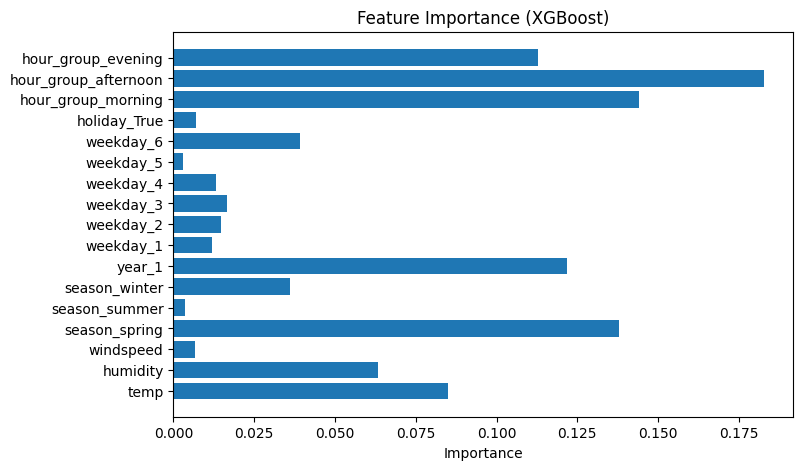

In [31]:
import matplotlib.pyplot as plt

importance = model_xgb.feature_importances_

plt.figure(figsize=(8, 5))
plt.barh(X.columns, importance)
plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance")
plt.show()

In [33]:
import pandas as pd

# Get importance scores (by gain)
booster = model_xgb.get_booster()

importance_dict = booster.get_score(importance_type="gain")

# Convert to DataFrame
importance_df = pd.DataFrame({
    "Feature": list(importance_dict.keys()),
    "Gain": list(importance_dict.values())
})

# Sort from most important to least
importance_df = importance_df.sort_values(by="Gain", ascending=False)

importance_df

,Feature,Gain
15,hour_group_afternoon,2.505187e+06
14,hour_group_morning,1.975317e+06
3,season_spring,1.889757e+06
6,year_1,1.671451e+06
16,hour_group_evening,1.545370e+06
0,temp,1.164964e+06
1,humidity,8.685301e+05
12,weekday_6,5.367573e+05
5,season_winter,4.960056e+05
9,weekday_3,2.273749e+05


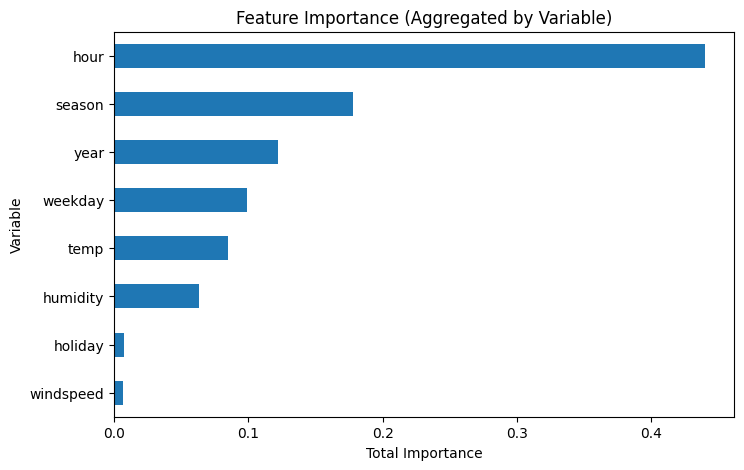

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature names and importance
feature_names = X.columns
importance = model_xgb.feature_importances_

# Create DataFrame
feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importance
})

# Function to extract base variable name
def get_base_feature(name):
    return name.split("_")[0]

# Apply grouping
feat_imp["base_feature"] = feat_imp["feature"].apply(get_base_feature)

# Aggregate importance by base feature
agg_imp = feat_imp.groupby("base_feature")["importance"].sum().sort_values()

# Plot
plt.figure(figsize=(8, 5))
agg_imp.plot(kind="barh")

plt.title("Feature Importance (Aggregated by Variable)")
plt.xlabel("Total Importance")
plt.ylabel("Variable")

plt.show()

In [36]:
from xgboost import XGBRegressor

model_xgb_1 = XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1)
model_xgb_2 = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05)
model_xgb_3 = XGBRegressor(n_estimators=150, max_depth=5, learning_rate=0.1)

models = [model_xgb_1, model_xgb_2, model_xgb_3]

for i, m in enumerate(models):
    m.fit(X_train, y_train)
    y_pred = m.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    print(f"Model {i+1} -> RMSE: {rmse:.2f}, R2: {r2:.3f}")

Model 1 -> RMSE: 113.49, R2: 0.593
Model 2 -> RMSE: 117.06, R2: 0.567
Model 3 -> RMSE: 110.47, R2: 0.615


We vary the hyperparameters to show robustness of results. The performance of the model is stable across different configurations and exhibit similar R2 scores. Below we use the hyperparameters of the third model in displaying the ranking of the features/variables (since it has the highest R2 and lowest RMSE).

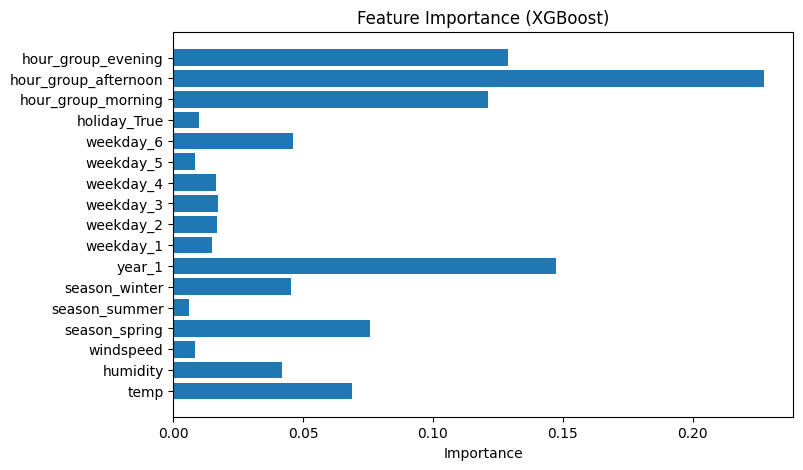

In [37]:
import pandas as pd

# Select the same variables as your final (third-level) model
X = df[[
    "temp", "humidity", "windspeed",
    "season", "year", "weekday", "hour_group",
    "holiday"
]].copy()

y = df["count"]

# Convert categorical variables to dummies
X = pd.get_dummies(X, columns=["season", "year", "weekday", "holiday", "hour_group"], drop_first=True)

X.head()

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from xgboost import XGBRegressor

model_xgb = XGBRegressor(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

model_xgb.fit(X_train, y_train)

import matplotlib.pyplot as plt

importance = model_xgb.feature_importances_

plt.figure(figsize=(8, 5))
plt.barh(X.columns, importance)
plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance")
plt.show()

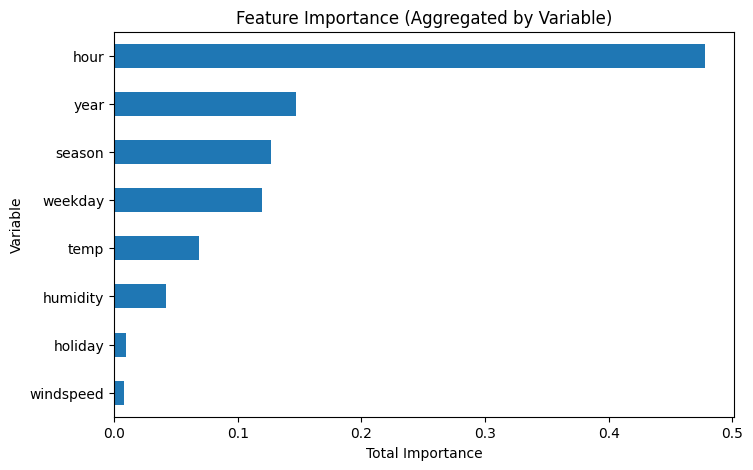

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature names and importance
feature_names = X.columns
importance = model_xgb.feature_importances_

# Create DataFrame
feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importance
})

# Function to extract base variable name
def get_base_feature(name):
    return name.split("_")[0]

# Apply grouping
feat_imp["base_feature"] = feat_imp["feature"].apply(get_base_feature)

# Aggregate importance by base feature
agg_imp = feat_imp.groupby("base_feature")["importance"].sum().sort_values()

# Plot
plt.figure(figsize=(8, 5))
agg_imp.plot(kind="barh")

plt.title("Feature Importance (Aggregated by Variable)")
plt.xlabel("Total Importance")
plt.ylabel("Variable")

plt.show()

###### Interpretation of results: 

Results are similar across the different specifications. The time of the day variable is the strongest predictor of bike rentals. It is followed by seasonal and year patterns. The day of the week and weather-related variables also matter, but have a much lower contribution. 

### Bibliography:

Chen, Tianqi, and Carlos Guestrin. “XGBoost: A Scalable Tree Boosting System.” Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining (KDD ’16), 2016, arXiv:1603.02754

Fanaee-T, H., & Gama, J. (2014). Event labeling combining ensemble detectors and background knowledge.

Fishman, E. (2016). Bikeshare: A review of recent literature. Transport Reviews.

Gujarati, D. N., & Porter, D. C. (2009). Basic Econometrics (5th ed.). McGraw-Hill.

Wooldridge, J. M. (2013). Introductory Econometrics: A Modern Approach.